Pruebas ML modelos de aprendizaje supervisado

Voy a utilizar Random Forest para experimentar posibles mejoras/cambios posibles en la evaluacion de datos del dataset

Imports y constructores


In [1]:
import sys
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline


sys.path.append(os.path.abspath(".."))
ruta_datos = "../Datos_preparados_iomt2024"


x_train_binario = pd.read_csv(f"{ruta_datos}/binario_train_X.csv")
y_train_binario = pd.read_csv(f"{ruta_datos}/binario_train_Y.csv").squeeze()

x_val_binario = pd.read_csv(f"{ruta_datos}/binario_val_X.csv")
y_val_binario = pd.read_csv(f"{ruta_datos}/binario_val_Y.csv").squeeze()

x_test_known_binario = pd.read_csv(f"{ruta_datos}/binario_test_known_X.csv")
y_test_known_binario = pd.read_csv(f"{ruta_datos}/binario_test_known_Y.csv").squeeze()

x_test_zeroday_binario = pd.read_csv(f"{ruta_datos}/binario_test_zeroday_X.csv")
y_test_zeroday_binario = pd.read_csv(f"{ruta_datos}/binario_test_zeroday_Y.csv").squeeze()

x_train_multiclase = pd.read_csv(f"{ruta_datos}/multiclase_train_X.csv")
y_train_multiclase = pd.read_csv(f"{ruta_datos}/multiclase_train_Y.csv").squeeze()

x_val_multiclase = pd.read_csv(f"{ruta_datos}/multiclase_val_X.csv")
y_val_multiclase = pd.read_csv(f"{ruta_datos}/multiclase_val_Y.csv").squeeze()

x_test_known_multiclase = pd.read_csv(f"{ruta_datos}/multiclase_test_known_X.csv")
y_test_known_multiclase = pd.read_csv(f"{ruta_datos}/multiclase_test_known_Y.csv").squeeze()

x_test_zeroday_multiclase = pd.read_csv(f"{ruta_datos}/multiclase_test_zeroday_X.csv")
y_test_zeroday_multiclase = pd.read_csv(f"{ruta_datos}/multiclase_test_zeroday_Y.csv").squeeze()

In [ ]:
from Scripts_modelos_supervisados.randomforest import construccion_rf_pipeline, evaluar_rf_binario, evaluar_rf_multiclase

carpeta_salida_rf = "Resultados_oruebas/Actualizado"
os.makedirs(carpeta_salida_rf, exist_ok=True)

Random Forest - Sin balanceo

In [ ]:
rf_pipe_binario = construccion_rf_pipeline(n_estimators=100, class_weight=None, n_jobs=-1, random_state=19)
rf_pipe_binario.fit(x_train_binario, y_train_binario)

# VALIDACION
print("\n==== RANDOM FOREST - VALIDACION - BINARIO - SIN BALANCEO ====")
reporte_texto_val_binario, reporte_dict_val_binario, matriz_val_binario, auc_val_binario = evaluar_rf_binario(
    rf_pipe_binario,
    x_val_binario,
    y_val_binario,
    carpeta_salida_rf,
    "roc_rf_val_binario_sinbalanceo.png"
)
print("Informe de clasificacion - Validacion - Binario:\n")
print(reporte_texto_val_binario)
display(pd.DataFrame(reporte_dict_val_binario).transpose().round(4))
print("\n Matriz de confusion - Validacion - Binario:\n")
print(matriz_val_binario)
    
if not np.isnan(auc_val_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Validacion - Binario: {auc_val_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

# TEST KNOWN
print("\n==== RANDOM FOREST - TEST KNOWN - BINARIO - SIN BALANCEO====")
reporte_texto_test_known_binario, reporte_dict_test_known_binario, matriz_test_known_binario, auc_test_known_binario = evaluar_rf_binario(
    rf_pipe_binario,
    x_test_known_binario,
    y_test_known_binario,
    carpeta_salida_rf,
    "roc_rf_test_known_binario_sinbalanceo.png"
)
print("Informe de clasificacion - Test known - Binario:\n")
print(reporte_texto_test_known_binario)
display(pd.DataFrame(reporte_dict_test_known_binario).transpose().round(4))
print("\n Matriz de confusion - Test known - Binario:\n")
print(matriz_test_known_binario)
    
if not np.isnan(auc_test_known_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test known - Binario: {auc_test_known_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

#Matriz de confusion binario - Test Known
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_known_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Random Forest - Test Known - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_rf, "matriz_confusion_rf_test_known_binario_sinbalanceo.png"))
plt.show()

# TEST ZERODAY
print("\n==== RANDOM FOREST - TEST ZERODAY - BINARIO - SIN BALANCEO====")
reporte_texto_test_zeroday_binario, reporte_dict_test_zeroday_binario, matriz_test_zeroday_binario, auc_test_zeroday_binario = evaluar_rf_binario(
    rf_pipe_binario,
    x_test_zeroday_binario,
    y_test_zeroday_binario,
    carpeta_salida_rf, 
    "roc_rf_test_zeroday_binario.png"
)
print("Informe de clasificacion - Test ZeroDay - Binario:\n")
print(reporte_texto_test_zeroday_binario)
display(pd.DataFrame(reporte_dict_test_zeroday_binario).transpose().round(4))
print("\n Matriz de confusion - Test ZeroDay - Binario\n")
print(matriz_test_zeroday_binario)
    
if not np.isnan(auc_test_zeroday_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test ZeroDay - Binario: {auc_test_zeroday_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

#Matriz de confusion binario - Test ZeroDay
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_zeroday_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Random Forest - Test ZeroDay - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_rf, "matriz_confusion_rf_test_zeroday_binario_sinbalanceo.png"))
plt.show()

#Tasa de deteccion de ataques ZeroDay en clasificador binario
tp_zeroday = matriz_test_zeroday_binario[1, 1]
fn_zeroday = matriz_test_zeroday_binario[1, 0]

if (tp_zeroday + fn_zeroday) > 0:
    tasa_deteccion_zeroday_bal = tp_zeroday / (tp_zeroday + fn_zeroday)
    print(f"Tasa de detección de ataques ZeroDay - Binario: {tasa_deteccion_zeroday_bal:.4f}")
else:
    print("No fue posible calcular la tasa de detección de ataques ZeroDay para clasificador binario.")

Random Forest - Con balanceo


Train binario:
Binary_label
1    5869315
0      17362
Name: count, dtype: int64

Val binario:
Binary_label
1    652147
0      1929
Name: count, dtype: int64

Test known binario:
Binary_label
1    1984514
0      37604
Name: count, dtype: int64

Test zeroday binario:
Binary_label
1    98418
Name: count, dtype: int64

==== RANDOM FOREST - VALIDACION (BINARIO) ====
Informe de clasificacion (binario):

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1929
           1       1.00      1.00      1.00    652147

    accuracy                           1.00    654076
   macro avg       0.99      0.98      0.98    654076
weighted avg       1.00      1.00      1.00    654076


 Matriz de confusion

[[  1863     66]
 [    53 652094]]

Area bajo la curva ROC (AUC): 0.999

==== RANDOM FOREST - TEST KNOWN (BINARIO) ====
Informe de clasificacion (binario):

              precision    recall  f1-score   support

           0       0.00      0.00    

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

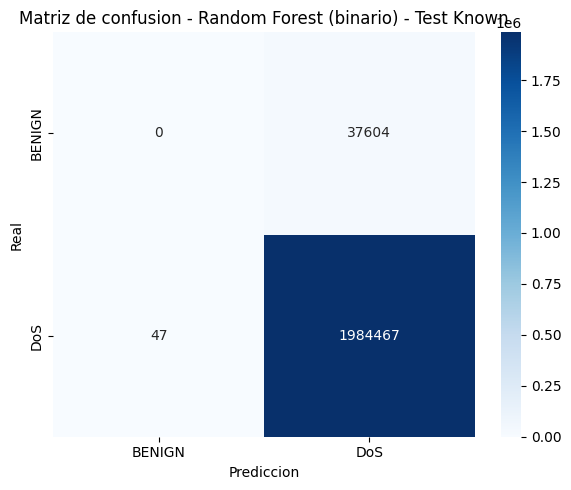

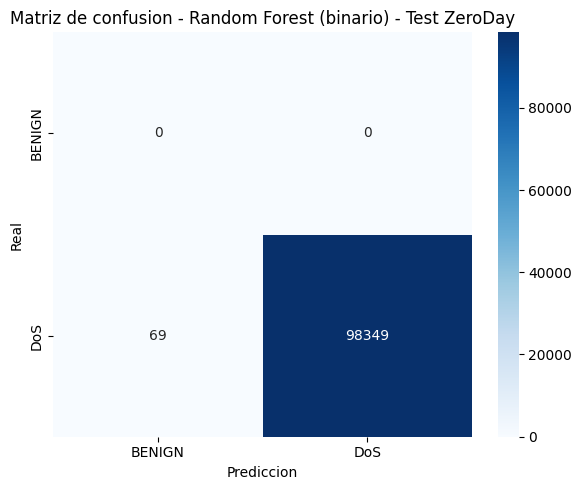

Tasa de deteccion del ataque ZeroDay: 0.9993

==== RANDOM FOREST - VALIDACION (MULTICLASE) ====
Informe de clasificacion (multiclase):

              precision    recall  f1-score   support

      Benign       0.97      0.98      0.97      1929
        DDoS       0.96      0.90      0.93    496693
         DoS       0.71      0.86      0.78    144636
   Malformed       0.83      0.80      0.81       505
       Recon       0.96      0.97      0.97      8716
    Spoofing       0.78      0.77      0.77      1597

    accuracy                           0.89    654076
   macro avg       0.87      0.88      0.87    654076
weighted avg       0.90      0.89      0.90    654076


Matriz de confusion:

[[  1882     23     24      0      0      0]
 [    24 447142  49525      0      1      1]
 [    36  20396 124202      0      1      1]
 [     0      0      0    404     27     74]
 [     0      0      0     13   8427    276]
 [     0      0      0     72    293   1232]]

Area bajo la curva ROC (AU

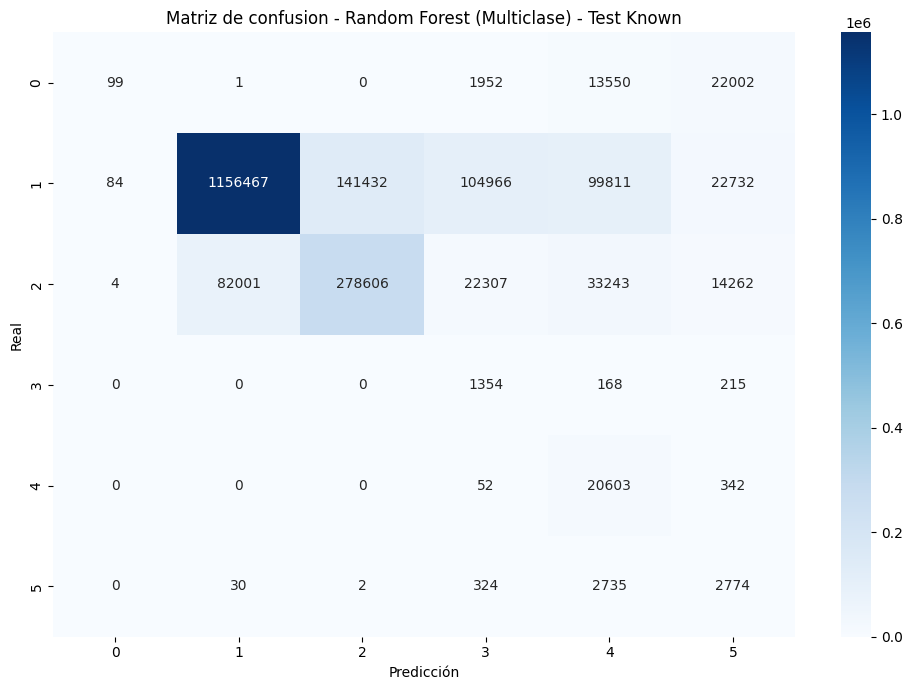

In [ ]:
from Scripts_modelos_supervisados.randomforest import construccion_rf_pipeline, evaluar_rf_binario, evaluar_rf_multiclase

carpeta_salida_rf = "Resultados_pruebas/RandomForest"
os.makedirs(carpeta_salida_rf, exist_ok=True)

#PRUEBAS DE DISTRIBUCION DE DATOS:
print("Train binario:")
print(y_train_binario.value_counts())
print("\nVal binario:")
print(y_val_binario.value_counts())
print("\nTest known binario:")
print(y_test_known_binario.value_counts())
print("\nTest zeroday binario:")
print(y_test_zeroday_binario.value_counts())


rf_pipe_binario = construccion_rf_pipeline(100, 19, -1, "balanced")
rf_pipe_binario.fit(x_train_binario, y_train_binario)

print("\n==== RANDOM FOREST - VALIDACION (BINARIO) ====")
reporte_val_binario, matriz_val_binario, auc_val_binario = evaluar_rf_binario(rf_pipe_binario, x_val_binario, y_val_binario, carpeta_salida_rf, "roc_rf_val_binario.png")

print("\n==== RANDOM FOREST - TEST KNOWN (BINARIO) ====")
reporte_test_known_binario, matriz_test_known_binario, auc_test_known_binario = evaluar_rf_binario(rf_pipe_binario, x_test_known_binario, y_test_known_binario, carpeta_salida_rf, "roc_rf_test_known_binario.png")

print("\n==== RANDOM FOREST - TEST ZERODAY (BINARIO) ====")
reporte_test_zeroday_binario, matriz_test_zeroday_binario, auc_test_zeroday_binario = evaluar_rf_binario(rf_pipe_binario, x_test_zeroday_binario, y_test_zeroday_binario, carpeta_salida_rf, "roc_rf_test_zeroday_binario.png")


print("Orden de clases:", rf_pipe_binario.named_steps["rf"].classes_)

plt.figure(figsize = (6,5))
sns.heatmap(matriz_test_known_binario, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = ['BENIGN', 'DoS'], yticklabels = ['BENIGN', 'DoS'])
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title("Matriz de confusion - Random Forest (binario) - Test Known")
plt.tight_layout()
plt.savefig(f"{carpeta_salida_rf}/matriz_confusion_rf_binario_test_known.png")
plt.show()

plt.figure(figsize = (6,5))
sns.heatmap(matriz_test_zeroday_binario, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = ['BENIGN', 'DoS'], yticklabels = ['BENIGN', 'DoS'])
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title("Matriz de confusion - Random Forest (binario) - Test ZeroDay")
plt.tight_layout()
plt.savefig(f"{carpeta_salida_rf}/matriz_confusion_rf_binario_test_zeroday.png")
plt.show()

tp_zeroday = matriz_test_zeroday_binario[1, 1]
fn_zeroday = matriz_test_zeroday_binario[1, 0]

if(tp_zeroday + fn_zeroday) > 0:
    tasa_deteccion_zeroday = tp_zeroday / (tp_zeroday + fn_zeroday)
    print(f"Tasa de deteccion del ataque ZeroDay: {tasa_deteccion_zeroday:.4f}")
else:
    print("No fue posible calcular la tasa de deteccion ZeroDay")

# MULTICLASE
rf_pipe_multiclase = construccion_rf_pipeline(100, 19, -1, "balanced")
rf_pipe_multiclase.fit(x_train_multiclase, y_train_multiclase)

print("\n==== RANDOM FOREST - VALIDACION (MULTICLASE) ====")
reporte_val_multiclase, matriz_val_multiclase, auc_val_multiclase = evaluar_rf_multiclase(rf_pipe_multiclase, x_val_multiclase, y_val_multiclase, carpeta_salida_rf, "roc_rf_val_multiclase.png")

print("\n==== RANDOM FOREST - TEST KNOWN (MULTICLASE) ====")
reporte_test_known_multiclase, matriz_test_known_multiclase, auc_test_known_multiclase = evaluar_rf_multiclase(rf_pipe_multiclase, x_test_known_multiclase, y_test_known_multiclase, carpeta_salida_rf, "roc_rf_test_known_multiclase.png")

print("\n==== RANDOM FOREST - TEST ZERODAY (MULTICLASE) ====")
reporte_test_zeroday_multiclase, matriz_test_zeroday_multiclase, auc_test_zeroday_multiclase = evaluar_rf_multiclase(rf_pipe_multiclase, x_test_zeroday_multiclase, y_test_zeroday_multiclase, carpeta_salida_rf, "roc_rf_test_zeroday_multiclase.png")

#Matriz de confusion 
plt.figure(figsize=(10,7))
sns.heatmap(matriz_test_known_multiclase, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Random Forest (Multiclase) - Test Known")
plt.tight_layout()
plt.savefig(f"{carpeta_salida_rf}/matriz_confusion_rf_multiclase_test_known.png")
plt.show()

Prueba Undersampling - Random Forest 

In [ ]:
#UNDERSAMPLING 1:1

# 1-Unimos X e Y para poder muestrear comodamente
df_train_binario = x_train_binario.copy()
df_train_binario["Binary_label"] = y_train_binario.values

# 2-Separamos clases
df_benigno = df_train_binario[df_train_binario["Binary_label"] == 0].copy()
df_ataque = df_train_binario[df_train_binario["Binary_label"] == 1].copy()

# 3-Undersampling de la clase mayoritaria (ataques)
df_ataque_muestras = df_ataque.sample(n=len(df_benigno), random_state=19)

# 4-Unimos benignos + ataques muestreados
df_train = pd.concat([df_benigno, df_ataque_muestras], axis=0)

# 5-Mezclamos filas
df_train = df_train.sample(frac=1, random_state=19).reset_index(drop=True)

# 6-Volvemos a separar X e Y
x_train_binario_undersampling = df_train.drop(columns=["Binary_label"])
y_train_binario_undersampling = df_train["Binary_label"]

print("\nDistribución train binario con undersampling:")
print(y_train_binario_undersampling.value_counts())
print("\nTamaño de X:", x_train_binario_undersampling.shape)
print("Tamaño de Y:", y_train_binario_undersampling.shape)

Mejor respuesta en la evaluacion con undersampling 1:1

Distribución original del train binario:
Binary_label
1    5869315
0      17362
Name: count, dtype: int64

Distribución del train binario balanceado:
Binary_label
0    17362
1    17362
Name: count, dtype: int64

Forma de X balanceado: (34724, 38)
Forma de Y balanceado: (34724,)

==== RANDOM FOREST BALANCEADO - VALIDACION (BINARIO) ====
Informe de clasificacion (binario):

              precision    recall  f1-score   support

           0       0.52      1.00      0.69      1929
           1       1.00      1.00      1.00    652147

    accuracy                           1.00    654076
   macro avg       0.76      1.00      0.84    654076
weighted avg       1.00      1.00      1.00    654076


 Matriz de confusion

[[  1929      0]
 [  1753 650394]]

Area bajo la curva ROC (AUC): 1.000

==== RANDOM FOREST BALANCEADO - TEST KNOWN (BINARIO) ====
Informe de clasificacion (binario):

              precision    recall  f1-score   support

           0       0.33      0.28      0.30     3760

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

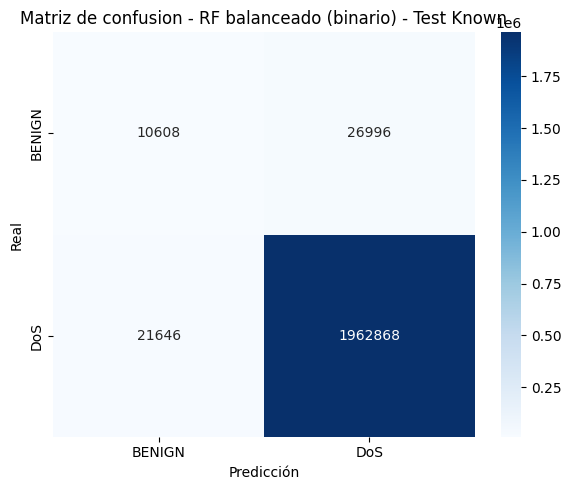

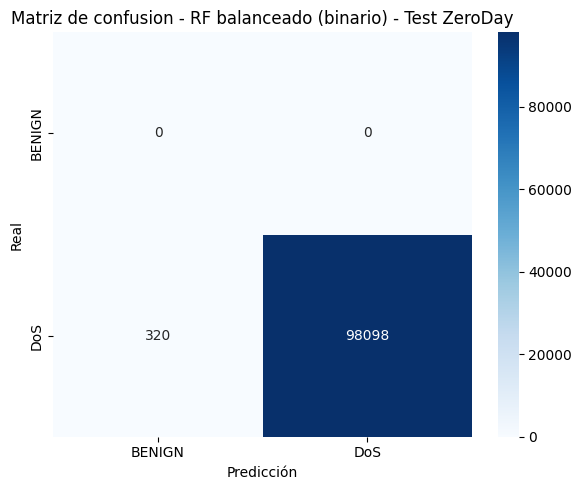

Tasa de detección del ataque ZeroDay (RF balanceado): 0.9967


In [ ]:
from Scripts_modelos_supervisados.randomforest import construccion_rf_pipeline, evaluar_rf_binario, evaluar_rf_multiclase

rf_pipe_binario_balanceado = construccion_rf_pipeline(100, 19, -1, "balanced")
rf_pipe_binario_balanceado.fit(x_train_binario_undersampling, y_train_binario_undersampling)

print("\n==== RANDOM FOREST BALANCEADO - VALIDACION (BINARIO) ====")
reporte_val_binario_bal, matriz_val_binario_bal, auc_val_binario_bal = evaluar_rf_binario(
    rf_pipe_binario_balanceado,
    x_val_binario,
    y_val_binario,
    carpeta_salida_rf,
    "roc_rf_balanceado_val_binario.png"
)

print("\n==== RANDOM FOREST BALANCEADO - TEST KNOWN (BINARIO) ====")
reporte_test_known_binario_bal, matriz_test_known_binario_bal, auc_test_known_binario_bal = evaluar_rf_binario(
    rf_pipe_binario_balanceado,
    x_test_known_binario,
    y_test_known_binario,
    carpeta_salida_rf,
    "roc_rf_balanceado_test_known_binario.png"
)

print("\n==== RANDOM FOREST BALANCEADO - TEST ZERODAY (BINARIO) ====")
reporte_test_zeroday_binario_bal, matriz_test_zeroday_binario_bal, auc_test_zeroday_binario_bal = evaluar_rf_binario(
    rf_pipe_binario_balanceado,
    x_test_zeroday_binario,
    y_test_zeroday_binario,
    carpeta_salida_rf, 
    "roc_rf_test_zeroday_binario.png"
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_known_binario_bal,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - RF balanceado (binario) - Test Known")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_zeroday_binario_bal,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - RF balanceado (binario) - Test ZeroDay")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_rf, "matriz_confusion_rf_balanceado_test_zeroday.png"))
plt.show()

tp_zeroday_bal = matriz_test_zeroday_binario_bal[1, 1]
fn_zeroday_bal = matriz_test_zeroday_binario_bal[1, 0]

if (tp_zeroday_bal + fn_zeroday_bal) > 0:
    tasa_deteccion_zeroday_bal = tp_zeroday_bal / (tp_zeroday_bal + fn_zeroday_bal)
    print(f"Tasa de detección del ataque ZeroDay (RF balanceado): {tasa_deteccion_zeroday_bal:.4f}")
else:
    print("No fue posible calcular la tasa de detección ZeroDay del modelo balanceado.")

Pruebas multiclase - Balanceo + Undersampling de la clase mayoritaria

Reducimos el numero de datos del dataset para las clases que tengan mas de 200.000 muestras, dejando el limite en 200.000

Distribucion original de train multiclase:
Attack_family
DDoS         4470228
DoS          1301724
Recon          78445
Benign         17362
Spoofing       14376
Malformed       4542
Name: count, dtype: int64

Distribución del train binario balanceado:
Attack_family
DDoS         100000
DoS          100000
Recon         78445
Benign        17362
Spoofing      14376
Malformed      4542
Name: count, dtype: int64

Forma de X balanceado: (314725, 38)
Forma de Y balanceado: (314725,)

==== RANDOM FOREST - VALIDACION (MULTICLASE) ====
Informe de clasificacion (multiclase):

              precision    recall  f1-score   support

      Benign       0.84      1.00      0.91      1929
        DDoS       0.97      0.87      0.92    496693
         DoS       0.67      0.90      0.77    144636
   Malformed       0.82      0.81      0.82       505
       Recon       0.96      0.97      0.96      8716
    Spoofing       0.78      0.77      0.77      1597

    accuracy                           0.88   

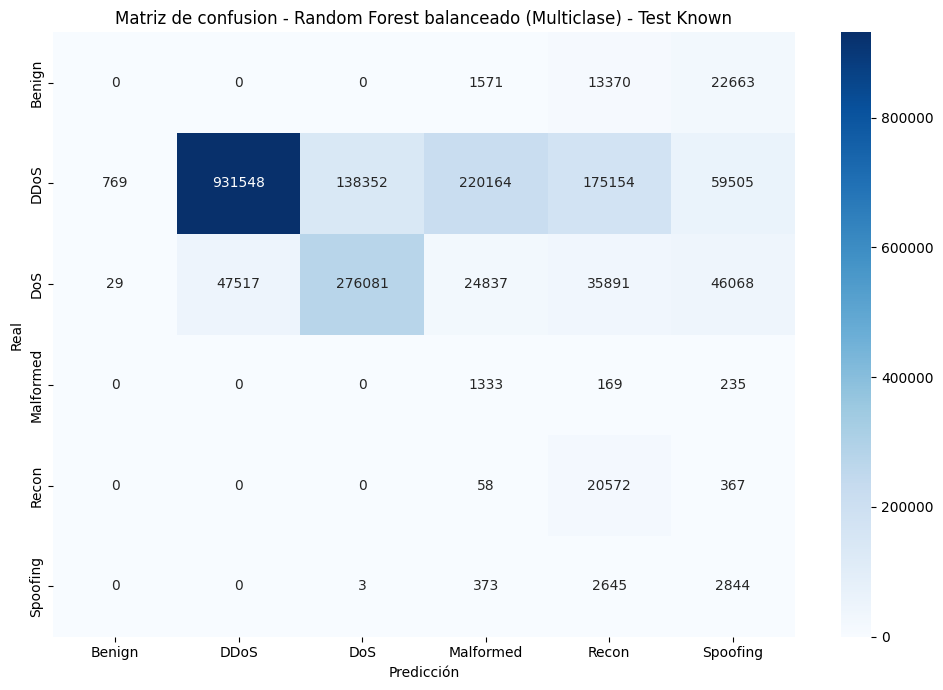

In [ ]:
# MULTICLASE
from Scripts_modelos_supervisados.randomforest import construccion_rf_pipeline, evaluar_rf_binario, evaluar_rf_multiclase

carpeta_salida_rf = "Resultados_pruebas/RandomForest"
os.makedirs(carpeta_salida_rf, exist_ok=True)

df_train_multiclase = x_train_multiclase.copy()
df_train_multiclase["Attack_family"]= y_train_multiclase.values

print("Distribucion original de train multiclase:")
print(df_train_multiclase["Attack_family"].value_counts())

max_muestras_por_clase = 200000
partes_balanceadas = []

for clase, grupo in df_train_multiclase.groupby("Attack_family"):
    if len(grupo) > max_muestras_por_clase:
        grupo_muestreado = grupo.sample(n=max_muestras_por_clase, random_state=19)
    else:
        grupo_muestreado = grupo.copy()
    partes_balanceadas.append(grupo_muestreado)

df_train_multiclase_bal = pd.concat(partes_balanceadas, axis=0)
df_train_multiclase_bal = df_train_multiclase_bal.sample(frac=1, random_state=19).reset_index(drop=True)

x_train_multiclase_bal = df_train_multiclase_bal.drop(columns=["Attack_family"])
y_train_multiclase_bal = df_train_multiclase_bal["Attack_family"]

print("\nDistribución del train binario balanceado:")
print(y_train_multiclase_bal.value_counts())
print("\nForma de X balanceado:", x_train_multiclase_bal.shape)
print("Forma de Y balanceado:", y_train_multiclase_bal.shape)

rf_pipe_multiclase_bal = construccion_rf_pipeline(100, 19, -1, "balanced")
rf_pipe_multiclase_bal.fit(x_train_multiclase_bal, y_train_multiclase_bal)

print("\n==== RANDOM FOREST - VALIDACION (MULTICLASE) ====")
reporte_val_multiclase_bal, matriz_val_multiclase_bal, auc_val_multiclase_bal = evaluar_rf_multiclase(rf_pipe_multiclase_bal, x_val_multiclase, y_val_multiclase, carpeta_salida_rf, "roc_rf_balanceado_val_multiclase.png")

print("\n==== RANDOM FOREST - TEST KNOWN (MULTICLASE) ====")
reporte_test_known_multiclase_bal, matriz_test_known_multiclase_bal, auc_test_known_multiclase_bal = evaluar_rf_multiclase(rf_pipe_multiclase_bal, x_test_known_multiclase, y_test_known_multiclase, carpeta_salida_rf, "roc_rf_balanceado_test_known_multiclase.png")

print("\n==== RANDOM FOREST - TEST ZERODAY (MULTICLASE) ====")
reporte_test_zeroday_multiclase_bal, matriz_test_zeroday_multiclase_bal, auc_test_zeroday_multiclase_bal = evaluar_rf_multiclase(rf_pipe_multiclase_bal, x_test_zeroday_multiclase, y_test_zeroday_multiclase, carpeta_salida_rf, "roc_rf_balanceado_test_zeroday_multiclase.png")

#Matriz de confusion 
plt.figure(figsize=(10,7))
sns.heatmap(matriz_test_known_multiclase_bal, annot=True, fmt='d', cmap='Blues', xticklabels=clases_multiclase, yticklabels=clases_multiclase)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Random Forest balanceado (Multiclase) - Test Known")
plt.tight_layout()
plt.savefig(f"{carpeta_salida_rf}/matriz_confusion_rf_balanceado_multiclase_test_known.png")
plt.show()